In [1]:
# In your notebook cell:
%pip uninstall -y google
%pip install google-generativeai


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [25]:
# Cell 1: Import necessary libraries

#reload libs

import sys
import os
from pathlib import Path
import pandas as pd
import openai
from typing import Dict, List, Tuple
import json
import google.generativeai as genai
import torch
print("Success! Version:", genai.__version__)

# Add the src directory to the path
sys.path.append(str(Path.cwd().parent / "src"))

from anaphor_comprehension_analyzer import AnaphorComprehensionAnalyzer as analyzer

from automated_scorer import AutomatedScorer

print("Libraries imported successfully!")


Success! Version: 0.8.5
Libraries imported successfully!


In [26]:
# In your notebook, add this before calling the method:
import importlib
import sys
sys.path.append(str(Path.cwd().parent / "src"))
import anaphor_comprehension_analyzer
importlib.reload(anaphor_comprehension_analyzer)
from anaphor_comprehension_analyzer import AnaphorComprehensionAnalyzer


In [18]:
# Cell 4: Load correct answers
# Load the correct answers for Study 1

def load_correct_answers(exp_num=1):
    if exp_num == 1:
        answers_file = Path.cwd().parent / "study 1 (context)" / "1 materials" / "scoring" / "question-scoring.xlsx"
    #correct_answers = scorer.load_correct_answers(study1_answers_file)
    elif exp_num == 2: 
        answers_file = Path.cwd().parent / "study 2 (semantics)" / "2 materials" / "scoring" / "quest-scoring.xlsx"

    df = pd.read_excel(str(answers_file))
    df.reset_index()
    #df.drop(columns=["GPT2"],  inplace=True)
    csv_answers = df.to_csv(f'study_{exp_num}_answers.csv', index=False)

    # Create correct answers dictionary
    correct_answers = {}
    for _, row in df.iterrows():
        # Convert passage number to 2-digit string (e.g., 1 -> "01")
        passage_num = str(row['Passage']).zfill(2)
        version = row['Version']
        question = row['Question']
        answer = row['Answer']
        
        # Create key as (passage, version, question)
        key = (passage_num, version, question)
        correct_answers[key] = answer

    print(f"Loaded {len(correct_answers)} correct answers")
    print("Sample correct answers:")
    for i, (key, answer) in enumerate(list(correct_answers.items())[:5]):
        print(f"  Passage {key[0]} Version {key[1]} Question {key[2]}: {answer}")
    return df





# # print("Excel file columns:", df.columns.tolist())
# print("First few rows:")
# print(df.head())

# print(f"Loaded {len(correct_answers)} correct answers")
# print("Sample correct answers:")
# for i, (key, answer) in enumerate(list(correct_answers.items())[:3]):
#     print(f"  {key}: {answer}")


In [19]:
#move over to function code

# Cell 4: Convert wide format to long format and load correct answers

from pathlib import Path

# Load the results from CSV

def _read_passage_text(file_path):
    """Read passage text from Study format file."""
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    text_lines = []
    for line in lines:
        if '\t' in line:
            text_content = line.split('\t', 1)[1].strip()
            if text_content:
                text_lines.append(text_content)
    
    passage = ' '.join(text_lines)
    return ' '.join(passage.split())


def _read_questions(file_path):
    """Read questions from Study format file."""
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    questions = []
    for line in lines:
        if '\t' in line:
            question = line.split('\t', 1)[1].strip()
            if question:
                questions.append(question)
    
    return questions


def _load_old_format(results):
    """Process the old format with full metadata."""
    long_results = []
    num_to_id = {1: 10, 2: 11, 3: 12}
    
    for idx, row in results.iterrows():
        questions = eval(row['questions'])  # Convert string to list
        
        for i, question in enumerate(questions, 1):
            question_col = f'question_{i}'
            if question_col in row:
                long_row = {
                    'study': row['study'],
                    'version': row['version'],
                    'passage_num': row['passage_num'],
                    'passage_file': row['passage_file'],
                    'passage_text': row['passage_text'],
                    'question_num': i,
                    'question': question,
                    'generated_answer': row[question_col]
                }
                long_results.append(long_row)
    
    results_df = pd.DataFrame(long_results)
    results_df['passage_key'] = results_df['passage_num'].astype(str).str.zfill(2)
    results_df['version'] = results_df['version'].astype(str).str.strip().str.upper()
    results_df['question_id'] = results_df['question_num'].map(num_to_id)
    
    return results_df


def _load_new_format(results, study_num=1):
    """
    Process the new format (indexed answers).
    Reconstructs passage/version/question mapping from index.
    """
    # Get the answer column name (second column)
    answer_col = results.columns[1]
    
    # For Study 1: 19 passages (01-20, skipping 04), 4 versions (A-D), 3 questions each
    # Order: For each passage, iterate through versions A, B, C, D, then questions 1, 2, 3
    passages = [f"{i:02d}" for i in range(1, 21) if i != 4]  # Skip passage 04
    versions = ['A', 'B', 'C', 'D']
    num_to_id = {1: 10, 2: 11, 3: 12}
    
    # Load questions from the study materials
    if study_num == 1:
        study_path = Path.cwd().parent / "study 1 (context)"
        materials_dir = study_path / "1 materials" / "passages"
    else:
        study_path = Path.cwd().parent / "study 2 (semantics)"
        materials_dir = study_path / "2 materials" / "passages"
    
    questions_dir = materials_dir / "questions"
    passages_dir = materials_dir / "40 column versions"
    
    long_results = []
    answer_idx = 0
    
    for passage_num in passages:
        for version in versions:
            # Check if passage file exists
            passage_file = passages_dir / f"p{passage_num}{version}.txt"
            if not passage_file.exists():
                continue
            
            # Read passage text
            passage_text = _read_passage_text(passage_file)
            
            # Read questions
            question_file = questions_dir / f"q{passage_num}.txt"
            if not question_file.exists():
                continue
            
            questions = _read_questions(question_file)
            
            for q_num, question in enumerate(questions, 1):
                if answer_idx >= len(results):
                    break
                
                answer = results.iloc[answer_idx][answer_col]
                
                long_row = {
                    'study': f'study{study_num}',
                    'version': version,
                    'passage_num': int(passage_num),
                    'passage_file': f"p{passage_num}{version}.txt",
                    'passage_text': passage_text,
                    'question_num': q_num,
                    'question': question,
                    'generated_answer': answer
                }
                long_results.append(long_row)
                answer_idx += 1
    
    results_df = pd.DataFrame(long_results)
    results_df['passage_key'] = results_df['passage_num'].astype(str).str.zfill(2)
    results_df['version'] = results_df['version'].astype(str).str.strip().str.upper()
    results_df['question_id'] = results_df['question_num'].map(num_to_id)
    
    return results_df


def load_model_responses(model_response_file, study_num=1):
    """
    Load model responses from CSV file.
    Handles both old format (with metadata) and new format (indexed answers only).
    
    Args:
        model_response_file: Name of the CSV file
        study_num: Study number (1 or 2)
    """
    results_path = Path.cwd().parent / "results" / "model_responses" / f"study {study_num}" / model_response_file
    results = pd.read_csv(results_path)

    print(f"Original format: {len(results)} rows")
    print("Columns:", results.columns.tolist())

    # Check if this is the new format (just index and answer)
    if len(results.columns) == 2 and (results.columns[0] in ['', 'Unnamed: 0'] or 
                                       str(results.columns[0]).isdigit() or
                                       (len(results) > 0 and str(results.iloc[0, 0]).isdigit())):
        # New format: index, answer
        print("Detected new format (indexed answers)")
        results_df = _load_new_format(results, study_num)
    else:
        # Old format: has study, version, passage_num, etc.
        print("Detected old format (with metadata)")
        results_df = _load_old_format(results)

    print(f"Converted to long format: {len(results_df)} rows")
    print("Sample long format data:")
    print(results_df.head())
    return results_df

    # Load correct answers
    # study1_answers_file = Path.cwd().parent / "study 1 (context)" / "1 materials" / "scoring" / "question-scoring.xlsx"
    # df = pd.read_excel(str(study1_answers_file))

    # # Create correct answers dictionary
    # correct_answers = {}
    # for _, row in df.iterrows():
    #     passage_num = str(row['Passage']).zfill(2)
    #     version = row['Version']
    #     question = row['Question']
    #     answer = row['Answer']
        
    #     key = (passage_num, version, question)
    #     correct_answers[key] = answer

    # print(f"Loaded {len(correct_answers)} correct answers")


In [ ]:
import os
import google.generativeai as genai

genai.configure(api_key="<INSERT_API_KEY>")
for m in genai.list_models():
    # Only models that accept text generation (typical for chat/completion)
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

E0000 00:00:1776723499.087415 2216670 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [27]:
api_key = os.environ.get("GOOGLE_API_KEY")
scorer = AutomatedScorer(api_key=api_key)

# 1. Load correct answers for Study 3
correct_answers = scorer.load_study3_answers()
print(f"Loaded {len(correct_answers)} correct answers")
# Format: {(passage_num, question_num): answer}
# Example: {(1, 1): 'van', (1, 2): 'gum', ...}

# 2. Load model responses (converts CSV to long format)
model_responses = scorer.load_study3_model_responses("falcon-7b-instruct.csv")
print(f"Loaded {len(model_responses)} model responses")
# This will:
# - Parse the CSV format (Passage 1-64, Answer_Index 1-4)
# - Convert to long format with passage_num, version, question_num
# - Only include questions 1-2 (Answer_Index 1-2)
# - Add question text and passage text

# 3. Score the responses
scored_results = scorer.score_study3_answers(model_responses, correct_answers)
print(f"Scored {len(scored_results)} responses")


Loaded 32 correct answers
Loaded 64 rows from falcon-7b-instruct.csv
Columns: ['study', 'version', 'passage_num', 'passage_file', 'passage_text', 'questions', 'question_1', 'question_2', 'question_3', 'question_4', 'correct_answer_1', 'correct_answer_2']
Detected old format (with metadata columns)
Converted to long format: 128 rows
Passages: 16, Versions: 4
Loaded 128 model responses
Scoring passage 01 version A (2 questions)...
Error scoring passage 01 version A: 404 models/gemini-2.5-flash-preview-09-2025 is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Scoring passage 01 version B (2 questions)...


E0000 00:00:1776723562.688421 2216670 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


Error scoring passage 01 version B: 404 models/gemini-2.5-flash-preview-09-2025 is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Scoring passage 01 version C (2 questions)...
Error scoring passage 01 version C: 404 models/gemini-2.5-flash-preview-09-2025 is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Scoring passage 01 version D (2 questions)...
Error scoring passage 01 version D: 404 models/gemini-2.5-flash-preview-09-2025 is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Scoring passage 02 version A (2 questions)...
Error scoring passage 02 version A: 404 models/gemini-2.5-flash-preview-09-2025 is not found for API version v1beta, or is not supported for gene

In [ ]:
output_path = Path.cwd().parent/"results/automate_scores/study 3/falcon-7b-instruct"
scorer.save_results(scored_results, str(output_path))

# 5. Calculate passage-level accuracy (optional)
passage_accuracy = scorer.calculate_passage_accuracy(scored_results)
print(passage_accuracy.head())


In [ ]:
%load_ext autoreload
%autoreload 2

import importlib, automated_scorer
importlib.reload(automated_scorer)
from automated_scorer import AutomatedScorer

# 1. Load correct answers using the scorer method (not the notebook function)
scorer = AutomatedScorer(api_key="<INSERT_API_KEY>")
answers_file = Path.cwd().parent / "study 1 (context)" / "1 materials" / "scoring" / "question-scoring.xlsx"
correct_answers = scorer.load_correct_answers(str(answers_file))  # Use scorer method, pass string path
print(f"Loaded {len(correct_answers)} correct answers")
print("Sample keys:", list(correct_answers.keys())[:5])

# 2. Load model responses
model = "gpt2xl_new" 
model_responses = load_model_responses(f"{model}.csv", study_num=1)
print(f"Loaded {len(model_responses)} model responses")

# 3. Debug: Check if keys match
print("\nChecking key matching:")
sample_keys = []
for idx, row in model_responses.head(5).iterrows():
    lookup_key = (row['passage_key'], row['version'], row['question_id'])
    sample_keys.append(lookup_key)
    found = lookup_key in correct_answers
    print(f"  {lookup_key} -> Found: {found}, Answer: {correct_answers.get(lookup_key, 'NOT FOUND')}")

# 4. Use batch processing via score_all_answers
results = scorer.score_all_answers(model_responses, correct_answers)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries imported successfully!
Loaded 228 correct answers
Sample keys: [('01', 'A', 10), ('01', 'A', 11), ('01', 'A', 12), ('01', 'B', 10), ('01', 'B', 11)]
Original format: 76 rows
Columns: ['study', 'version', 'passage_num', 'passage_file', 'passage_text', 'questions', 'question_1', 'question_2', 'question_3']
Detected old format (with metadata)
Converted to long format: 228 rows
Sample long format data:
     study version  passage_num passage_file  \
0  study_1       A            1     p01A.txt   
1  study_1       A            1     p01A.txt   
2  study_1       A            1     p01A.txt   
3  study_1       A            2     p02A.txt   
4  study_1       A            2     p02A.txt   

                                        passage_text  question_num  \
0  Sophia straightened her suit, took a deep brea...             1   
1  Sophia straightened her suit, took a deep brea...             2   
2

E0000 00:00:1767561307.135196  473660 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


scored result:       study version  passage_num passage_file  \
0  study_1       A            1     p01A.txt   
1  study_1       A            1     p01A.txt   
2  study_1       A            1     p01A.txt   

                                        passage_text  question_num  \
0  Sophia straightened her suit, took a deep brea...             1   
1  Sophia straightened her suit, took a deep brea...             2   
2  Sophia straightened her suit, took a deep brea...             3   

                                            question  \
0  What amber beverage did Sophia leave back at t...   
1        What did Sophia do before she left the bar?   
2      Where was Sophia supposed to meet the client?   

                                    generated_answer passage_key  question_id  \
0                                     An amber beer.          01           10   
1  She waited for her driver's license to be proc...          01           11   
2                                   In a n

In [21]:
df = results[["version", "passage_num", "question_id", "question", "generated_answer", "gpt4_score", "gpt4_reasoning", "correct_answer"]]
automate_comprehension_scores_path = Path.cwd().parent / "results" / "automate_scores" / "study 1"
results_path = (automate_comprehension_scores_path / f"{model}.csv")
df.to_csv(results_path)


/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/pythia.csv
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/mistral7b.csv
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/mistral24b.csv
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/llama3.csv
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/falcon-7b-instruct.csv
/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 2/gpt2xl.csv
exp_num 2


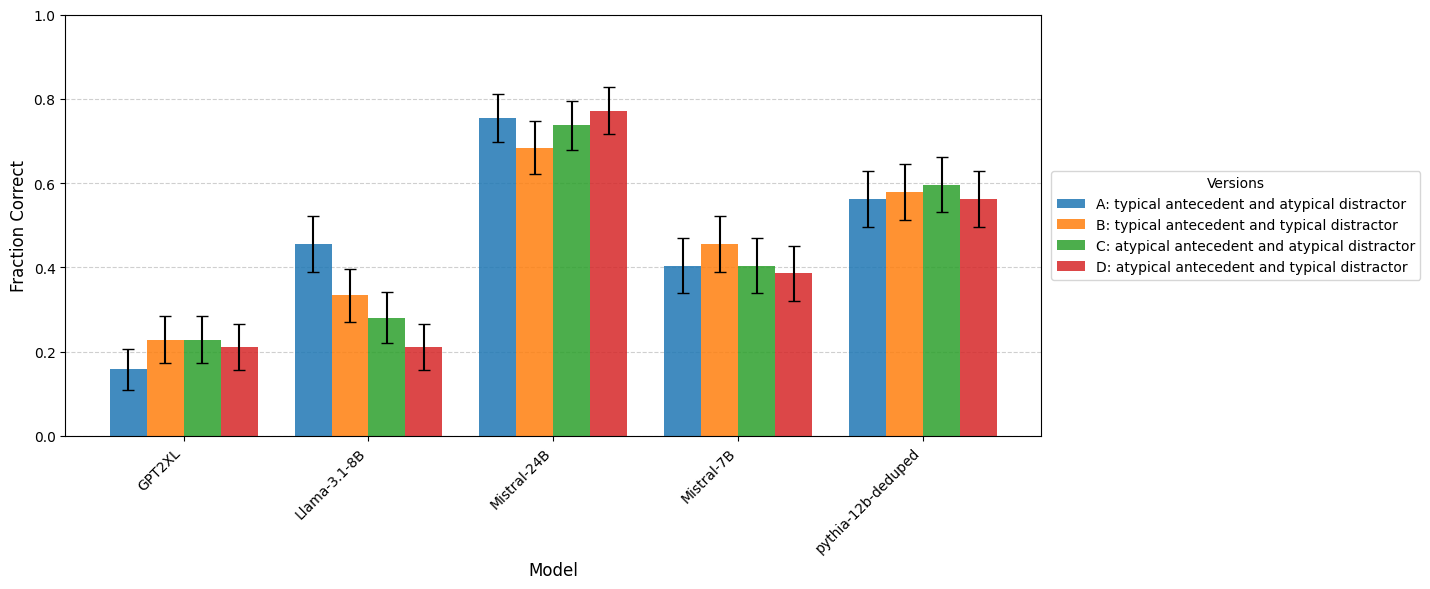

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def sem(x):
    """Calculate standard error of the mean."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def create_simple_accuracy_plot(data_dict, exp_num):
    """
    Create a simple bar plot showing accuracy by version for each model.
    Swaps B and C column names for exp 1.
    """
    
    # Prepare data and track which column is used
    print("exp_num", exp_num)
    plot_data = []
    score_column = None
    
    for model_name, df in data_dict.items():
        # Convert judge_score to binary (0/1) if needed
        if 'judge_score' in df.columns:
            df = df.copy()
            df['Correct'] = pd.to_numeric(df['judge_score'], errors='coerce')
            df['Correct'] = (df['Correct'] > 0).astype(int)
            score_column = 'Correct'
        elif 'accuracy' in df.columns:
            df = df.copy()
            df['Correct'] = pd.to_numeric(df['accuracy'], errors='coerce')
            df['Correct'] = (df['Correct'] > 0).astype(int)
            score_column = 'Correct'
        else:
            print(f"Warning: No accuracy data found for {model_name}")
            continue
        
        # Calculate accuracy by version with mean and SEM
        version_stats = df.groupby('version')[score_column].agg(mean='mean', sem=sem).reset_index()
            
        version_stats['model'] = model_name
        plot_data.append(version_stats)
    
    if not plot_data:
        print("No data to plot!")
        return
    
    # Combine all data
    combined_df = pd.concat(plot_data, ignore_index=True)
    
    # Swap B and C column names
    if exp_num == 1:
        combined_df['version'] = combined_df['version'].replace({'B': 'C_temp', 'C': 'B'})
        combined_df['version'] = combined_df['version'].replace({'C_temp': 'C'})
    else:
#         Version A: typical antecedent and typical distractor  (new B)
        # Version B: typical antecedent and atypical distractor (new A)
        # Version C: atypical antecedent and typical distractor  (new D)
        # Version D: atypical antecedent and atypical distractor (new C)

        combined_df['version'] = combined_df['version'].replace({
            'A': 'B_temp',
            'B': 'A',
            'C': 'D_temp',
            'D': 'C'
        })
        combined_df['version'] = combined_df['version'].replace({
            'B_temp': 'B',
            'D_temp': 'D'
        })
    # Create the plot with larger figure size for better visibility
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Set up bar positions - models on x-axis, versions as bars
    models = sorted(combined_df['model'].unique())
    versions = ['A', 'B', 'C', 'D']
    x_pos = np.arange(len(models))
    
    num_versions = len(versions)
    
    # Calculate width dynamically based on number of versions
    # Ensure bars don't overlap and have some spacing
    width = 0.8 / num_versions  # Total width of 0.8 divided by number of versions
    
    # More colors for better distinction (one per version)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    for i, version in enumerate(versions):
        # Get means and SEMs for this version across all models
        means = []
        sems = []
        for model in models:
            model_version_data = combined_df[(combined_df['model'] == model) & (combined_df['version'] == version)]
            if len(model_version_data) > 0:
                means.append(model_version_data['mean'].iloc[0])
                sems.append(model_version_data['sem'].iloc[0])
            else:
                means.append(0)
                sems.append(0)
        
        # Center bars around each model position
        offset = (i - (num_versions - 1) / 2) * width
        ax.bar(x_pos + offset, means, width, 
               yerr=sems,
               capsize=4,
               label=f'Version {version}', 
               color=colors[i % len(colors)], 
               alpha=0.85)
    
    # Customize the plot
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Fraction Correct', fontsize=12)
    
    # Set x-axis labels at model positions
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha='right')
    
    # Custom legend mapping
    if exp_num == 1:
        legend_labels = {
            "A": "A: near spatial distance, short temporal duration",
            "B": "B: near spatial distance, long temporal duration",
            "C": "C: far spatial distance, short temporal duration",
            "D": "D: far spatial distance, long temporal duration"
        }
    else:
        legend_labels = {
            "A": "A: typical antecedent and atypical distractor",
            "B": "B: typical antecedent and typical distractor",
            "C": "C: atypical antecedent and atypical distractor",
            "D": "D: atypical antecedent and typical distractor"
        }
    
    # Create custom legend handles
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [legend_labels[l.replace('Version ', '')] for l in labels]
    
    ax.legend(
        handles, 
        new_labels, 
        title="Versions",
        bbox_to_anchor=(1.01, 0.5),
        loc="center left",
        borderaxespad=0.,
        fontsize=10
    )
    
    # Add grid with matching style
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    
    # Set y-axis limits
    ax.set_ylim(0, 1)
    
    plt.tight_layout(rect=[0, 0, 1.2, 1])
    return fig, ax

automate_comprehension_scores_path = Path.cwd().parent / "results" / "automate_scores" / f"study 2"
#automate_comprehension_scores_path = Path.cwd().parent / "Graded Scores" / f"study 2" 

print(automate_comprehension_scores_path)
for file in automate_comprehension_scores_path.glob("*.csv"):
    print(file)

data_dict = {
    'GPT2XL': pd.read_csv(automate_comprehension_scores_path / "gpt2xl.csv"),
    'Llama-3.1-8B': pd.read_csv(automate_comprehension_scores_path / "llama3.csv"),#redo
    'pythia-12b-deduped': pd.read_csv(automate_comprehension_scores_path / "pythia.csv"),
    'Mistral-7B': pd.read_csv(automate_comprehension_scores_path / "mistral7b.csv"), #redo
    'Mistral-24B': pd.read_csv(automate_comprehension_scores_path / "mistral24b.csv"), #redo
}

fig, ax = create_simple_accuracy_plot(data_dict, exp_num=2)
plt.show()


In [ ]:
analyzer.


In [ ]:
df.to_excel("gemma.xlsx")


In [ ]:
final_df


In [ ]:
automate_comprehension_scores_path = Path.cwd().parent / "results" / "automate_scores"
result_path = automate_comprehension_scores_path / "gemma-7b.xlsx"
df.to_excel(result_path)


/Users/varshinichinta/Desktop/anaphor/results/automate_scores/study 1/gpt2xl.csv
   Unnamed: 0 version  passage_num  question_id  \
0           0       A            1           10   
1           1       A            1           11   
2           2       A            1           12   
3           3       B            1           10   
4           4       B            1           11   

                                            question  \
0  What amber beverage did Sophia leave back at t...   
1        What did Sophia do before she left the bar?   
2      Where was Sophia supposed to meet the client?   
3  What amber beverage did Sophia leave back at t...   
4        What did Sophia do before she left the bar?   

                                    generated_answer  judge_score  \
0                                     An amber beer.          1.0   
1  She waited for her driver's license to be proc...          0.0   
2                                   In a nearby bar.          0.0   

,FractionCorrect
Model,
GPT2,0.236842
LLaMa-3.1-8B,0.570175
pythia-12b-deduped,0.517544
Mistral-7B,0.425439
Mistral-24B,0.635965


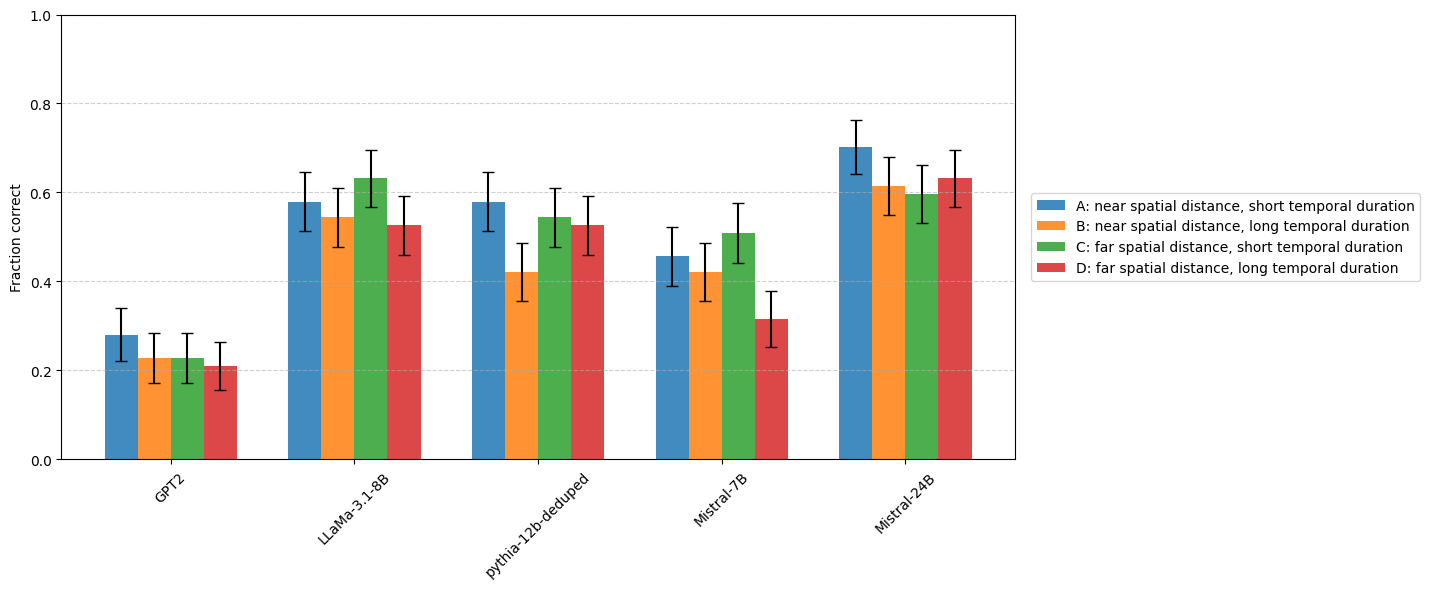

In [9]:
# plot results
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# --------- config ----------
folder = Path.cwd().parent / "results" / "automate_scores" / f"study 1"
#folder = Path.cwd().parent / "results" / "automate_scores" / f"study 1"

 
model_order = [
    "GPT2",
    "LLaMa-3.1-8B",
    "pythia-12b-deduped",
    "Mistral-7B",
    "Mistral-24B"
]
 
file_to_model = {
    "gpt2xl": "GPT2",
    "llama3": "LLaMa-3.1-8B",
    "pythia": "pythia-12b-deduped",
    "mistral7b": "Mistral-7B",
    "mistral24b": "Mistral-24B",
}
 
def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
 
# --------- load + stack CSVs ----------
rows = []
 
for path in sorted(glob.glob(os.path.join(folder, "*.csv"))):
    print(path)
    base = os.path.splitext(os.path.basename(path))[0].lower()
 
    model = None
    for k, v in file_to_model.items():
        if base == k or base.startswith(k):
            model = v
            break
 
    if model is None or model == "FALCON":
        continue
 
    df = pd.read_csv(path)
    print(df.head())
 
    required = {"judge_score", "version", "passage_num"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"{os.path.basename(path)} missing columns: {missing}")
 
    df = df.copy()
    df["Model"] = model
 
    # fraction-correct ONLY from gpt4_score
    # (treat >0 as correct; if it's already 0/1 this is unchanged)
    df["Correct"] = pd.to_numeric(df["judge_score"], errors="coerce")
    df["Correct"] = (df["Correct"] > 0).astype(int)
 
    # keep only what we need
    rows.append(df[["Model", "version", "passage_num", "Correct"]])

print("ROWS:\n", rows)
long_df = pd.concat(rows, ignore_index=True)
 
# enforce model order + expected versions
long_df = long_df[long_df["Model"].isin(model_order)].copy()
long_df["version"] = long_df["version"].astype(str).str.strip()
long_df = long_df[long_df["version"].isin(["A", "B", "C", "D"])]
 
# --------- 1) overall fraction correct ----------
overall = (
    long_df.groupby("Model")["Correct"]
    .mean()
    .reindex(model_order)
)
display(overall.to_frame("FractionCorrect"))
 
# --------- by-version stats (mean ± SEM across items) ----------
stats = (
    long_df.groupby(["Model", "version"])["Correct"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)
 
# --------- 2) plot grouped bars (A–D) ----------
models = [m for m in model_order if m in stats["Model"].unique()]
versions = ["A", "C", "B", "D"]
x = np.arange(len(models))
width = 0.18
 
plt.figure(figsize=(12, 6))
 
for i, v in enumerate(versions):
    sub = stats[stats["version"] == v].set_index("Model").reindex(models)
    plt.bar(
        x + i * width,
        sub["mean"].values,
        width,
        yerr=sub["sem"].values,
        capsize=4,
        label=v,
        alpha=0.85
    )
 
plt.xticks(x + width * (len(versions) - 1) / 2, models, rotation=45)
plt.ylim(0, 1)
plt.ylabel("Fraction correct")
plt.grid(axis="y", linestyle="--", alpha=0.6)
 
legend_labels = {
    "A": "A: near spatial distance, short temporal duration",
    "C": "B: near spatial distance, long temporal duration",
    "B": "C: far spatial distance, short temporal duration",
    "D": "D: far spatial distance, long temporal duration"
}
 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles,
    [legend_labels[l] for l in labels],
    bbox_to_anchor=(1.01, 0.5),
    loc="center left"
)
 
plt.tight_layout(rect=[0, 0, 1.2, 1])
plt.show()
 
